<a href="https://colab.research.google.com/github/SAMYSOSERIOUS/CS2_Knee_Xray/blob/test/ko_week5_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook: Model Implementation, Training & Ensemble Learning

**Official Name:** `ko_week5_7.ipynb`

---

## Project Context & Objectives

This notebook operationalizes the core experimental pipeline of the Knee Osteoarthritis (KOA) severity prediction study. It implements a **data-centric, ordinal-aware deep learning framework** designed to maximize **Quadratic Weighted Cohen’s Kappa (QWK)** while preserving **clinical plausibility and explainability**.

The work extends beyond single-model benchmarking by combining:

* Advanced preprocessing (CLAHE)
* Ordinal regression (CORAL)
* Strong modern architectures (EfficientNet, ConvNeXt, Swin Transformer)
* Snapshot ensembling, temperature scaling, and test-time augmentation (TTA)
* Hook-free Grad-CAM–based explainability

---

## Research Questions Addressed

**RQ1 – Comparative Performance**
How do different high-capacity architectures compare in terms of QWK when trained under identical preprocessing, loss, and validation protocols?

**RQ2 – Data-Centric Optimization**
What is the impact of contrast normalization (CLAHE), patient-aware cross-validation, and ordinal loss formulation on performance stability and generalization?

**RQ3 – Explainability & Clinical Plausibility**
Do Grad-CAM attention maps for top-performing models localize to anatomically meaningful knee joint regions relevant to KOA pathology?

**RQ4 – Error Analysis & Failure Modes**
Which severity grades are most frequently confused, and how do ensemble strategies mitigate systematic misclassification patterns?

---

## Success Criteria (from Project Exposé)

* **QWK > 0.75** for the best-performing model or ensemble
* **≥80%** of Grad-CAM visualizations judged clinically plausible
* Comparative evaluation across architectures
* Explicit reporting of training dynamics, validation loss, and ensemble behavior
* Environmental and computational cost awareness (batch size, AMP, early stopping)




## SECTION 0 — Comprehensive Setup with All Dependencies

**Purpose:** Ensure full reproducibility and deterministic behavior.

**Reasoning:**

* Fixed package versions prevent silent performance regressions.
* Global random seeding (Python, NumPy, PyTorch, CUDA) ensures experiment repeatability.
* cuDNN determinism is enforced to avoid non-deterministic kernel selection.
* Automatic device selection allows seamless execution on GPU or CPU.

This section establishes a *controlled experimental environment*, a prerequisite for any valid comparative study.




In [1]:
!pip install timm==0.9.3 opencv-python==4.8.1.76 matplotlib==3.8.0 kaggle==1.5.16 seaborn --quiet

import random, os, numpy as np, torch, gc, pandas as pd
from pathlib import Path
from PIL import Image
import cv2, torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import cohen_kappa_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import timm, torch.nn as nn, torch.optim as optim, zipfile

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device: {device}")

ERROR: Could not find a version that satisfies the requirement timm==0.9.3 (from versions: 0.1.1, 0.1.2, 0.1.4, 0.1.6, 0.1.8, 0.1.10, 0.1.12, 0.1.14, 0.1.16, 0.1.18, 0.1.20, 0.1.22, 0.1.24, 0.1.26, 0.1.28, 0.1.30, 0.2.1, 0.3.0, 0.3.1, 0.3.2, 0.3.3, 0.3.4, 0.4.5, 0.4.9, 0.4.12, 0.5.4, 0.6.2.dev0, 0.6.5, 0.6.7, 0.6.11, 0.6.12, 0.6.13, 0.8.0.dev0, 0.8.2.dev0, 0.8.3.dev0, 0.8.6.dev0, 0.8.10.dev0, 0.8.11.dev0, 0.8.13.dev0, 0.8.15.dev0, 0.8.17.dev0, 0.8.19.dev0, 0.8.21.dev0, 0.8.23.dev0, 0.9.0, 0.9.1, 0.9.2, 0.9.5, 0.9.6, 0.9.7, 0.9.8, 0.9.9, 0.9.10, 0.9.11, 0.9.12, 0.9.16, 1.0.3, 1.0.7, 1.0.8, 1.0.9, 1.0.10, 1.0.11, 1.0.12, 1.0.13, 1.0.14, 1.0.15, 1.0.16, 1.0.17, 1.0.18, 1.0.19, 1.0.20, 1.0.21, 1.0.22, 1.0.23, 1.0.24)
ERROR: No matching distribution found for timm==0.9.3
✅ Device: cuda



## SECTION 1 — Google Drive Mount & Project Structure

**Purpose:** Centralized artifact management.

**Reasoning:**

* Separating models, predictions, reports, charts, and data enforces clean experiment hygiene.
* Drive persistence prevents loss of checkpoints and metrics during Colab runtime resets.
* Folder abstraction enables scalable extension to multi-fold or multi-dataset experiments.



In [2]:
from google.colab import drive, files
DRIVE_BASE = "/content/drive"
drive.mount(DRIVE_BASE, force_remount=True)
BASE_DIR = Path(DRIVE_BASE) / "MyDrive/KOA_QWK_challenge"
folders = ["models","predictions","reports","charts","data"]
for f in folders: (BASE_DIR/f).mkdir(parents=True, exist_ok=True)
PATHS = {f: BASE_DIR/f for f in folders}
print("✅ Paths ready:", PATHS)

Mounted at /content/drive
✅ Paths ready: {'models': PosixPath('/content/drive/MyDrive/KOA_QWK_challenge/models'), 'predictions': PosixPath('/content/drive/MyDrive/KOA_QWK_challenge/predictions'), 'reports': PosixPath('/content/drive/MyDrive/KOA_QWK_challenge/reports'), 'charts': PosixPath('/content/drive/MyDrive/KOA_QWK_challenge/charts'), 'data': PosixPath('/content/drive/MyDrive/KOA_QWK_challenge/data')}


## SECTION 2 — Kaggle API Configuration

**Purpose:** Secure, reproducible dataset access.

**Reasoning:**

* Programmatic dataset access removes manual download errors.
* Proper permission handling (`chmod 600`) ensures API compliance.
* This step guarantees that all results can be regenerated from raw public data.


In [3]:
uploaded = files.upload()  # upload kaggle.json
kaggle_json_path = list(uploaded.keys())[0]
!mkdir -p ~/.kaggle
!cp "{kaggle_json_path}" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API configured.")

Saving kaggle.json to kaggle.json
✅ Kaggle API configured.


## SECTION 3 — Dataset Download & Extraction

**Purpose:** Unified ingestion of the KOA severity dataset.

**Reasoning:**

* Local caching avoids repeated downloads and reduces bandwidth usage.
* Explicit extraction ensures compatibility with downstream filesystem-based loaders.
* Abstracted import function allows easy dataset swapping if required.



In [4]:
def import_kaggle_dataset(dataset_name: str):
    CACHE_DIR = Path("/content/kaggle_cache")
    CACHE_DIR.mkdir(exist_ok=True)
    DATASET_PATH = CACHE_DIR / "dataset"
    if not DATASET_PATH.exists():
        !kaggle datasets download -d {dataset_name} -p {CACHE_DIR} --force
        zip_files = list(CACHE_DIR.glob("*.zip"))
        with zipfile.ZipFile(zip_files[0], "r") as zip_ref:
            zip_ref.extractall(DATASET_PATH)
    print("✅ Dataset ready.")
    return DATASET_PATH

shashwat_root = import_kaggle_dataset("shashwatwork/knee-osteoarthritis-dataset-with-severity")

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity
License(s): Attribution 4.0 International (CC BY 4.0)
 81% 165M/204M [00:00<00:00, 1.72GB/s]
100% 204M/204M [00:00<00:00, 1.72GB/s]
✅ Dataset ready.


## SECTION 4 — Dataset Cleaning & Integrity Validation

**Purpose:** Guarantee label correctness and image validity.

**Reasoning:**

* Image verification prevents runtime crashes during training.
* Folder-based label inference aligns with dataset structure.
* Patient-level identifiers are extracted to enable leakage-safe cross-validation.
* Combining splits allows **custom stratified group K-folds**, superior to predefined splits.




In [5]:
def clean_folder_dataset(root: Path, source_name: str):
    records, failed = [], []
    for folder, _, files in os.walk(root):
        folder_path = Path(folder)
        try: label = int(folder_path.name)
        except: continue
        for f in files:
            img_path = folder_path / f
            try:
                Image.open(img_path).verify()
                records.append({"image_path": str(img_path), "label": label, "source": source_name})
            except: failed.append(str(img_path))
    if failed: print(f"⚠️ {len(failed)} images failed in {source_name}")
    return pd.DataFrame(records)

shashwat_df = pd.concat([clean_folder_dataset(shashwat_root / s, f"shashwat_{s}")
                         for s in ['train','val','test']], ignore_index=True)

combined_df = shashwat_df
if 'patient_id' not in combined_df.columns:
    combined_df['patient_id'] = combined_df['image_path'].apply(lambda x: Path(x).stem.split("_")[0])
NUM_LABELS = int(combined_df['label'].nunique())
CORAL_DIM = NUM_LABELS-1
print("✅ Combined dataset:", len(combined_df))
print(combined_df['label'].value_counts())

✅ Combined dataset: 8260
label
0    3253
2    2175
1    1495
3    1086
4     251
Name: count, dtype: int64


## SECTION 5 — Preprocessing, Transforms & Dataset Class

**Purpose:** Robust and clinically motivated image preprocessing.

**Reasoning:**

* **CLAHE** enhances joint-space contrast critical for KOA grading.
* Data augmentation improves robustness without distorting anatomy.
* Normalization stabilizes optimization across architectures.
* Custom `Dataset` abstraction allows transparent error handling and extensibility.



In [6]:
class CLAHETransform:
    def __call__(self, img):
        g = np.array(img.convert("L"))
        g = cv2.createCLAHE(2.0, (8,8)).apply(g)
        g = np.stack([g]*3, axis=-1)
        return Image.fromarray(g)

class KOADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        try: img = Image.open(self.df.loc[idx,"image_path"]).convert("RGB")
        except: img = Image.new("RGB", (224,224), (0,0,0))
        label = self.df.loc[idx,"label"]
        if self.transform: img = self.transform(img)
        return img,label

def get_transforms(img_size=224, train=True, tta=False):
    tfms = [CLAHETransform(), T.Resize((img_size,img_size))]
    if train or tta: tfms += [T.RandomHorizontalFlip(), T.RandomRotation(10)]
    tfms += [T.ToTensor(), T.Normalize([0.5]*3,[0.5]*3)]
    return T.Compose(tfms)

## SECTION 6 — Patient-Aware Cross-Validation

**Purpose:** Prevent data leakage and optimistic bias.

**Reasoning:**

* `StratifiedGroupKFold` preserves class balance *and* patient separation.
* This is essential in medical imaging where multiple images per patient exist.
* Ensures validation performance reflects true generalization.



In [7]:
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(skf.split(combined_df, combined_df.label, combined_df.patient_id))
train_idx, val_idx = folds[0]
train_df = combined_df.iloc[train_idx].reset_index(drop=True)
val_df   = combined_df.iloc[val_idx].reset_index(drop=True)
print("Train:", len(train_df), "Val:", len(val_df))

Train: 6608 Val: 1652


## SECTION 7 — DataLoader Construction

**Purpose:** Efficient and consistent batch delivery.

**Reasoning:**

* Separate loaders for training, validation, and TTA avoid logic duplication.
* Pinned memory and parallel workers improve GPU throughput.
* Design supports heterogeneous image resolutions across models.



In [8]:
num_workers = 2
def make_loader(df, img_size=224, batch_size=8, train=True, tta=False):
    return DataLoader(KOADataset(df,get_transforms(img_size,train,tta)),
                      batch_size=batch_size, shuffle=train, num_workers=num_workers,
                      pin_memory=True)



## SECTION 8 — Ordinal Regression with CORAL Loss

**Purpose:** Respect the ordered nature of KOA severity grades.

**Reasoning:**

* KOA grades are ordinal, not categorical.
* CORAL converts classification into cumulative binary decisions.
* This aligns the optimization objective with QWK, reducing severe mis-rankings.



In [9]:
class CoralLoss(nn.Module):
    def forward(self, logits, labels):
        cum_labels = torch.arange(logits.size(1)).unsqueeze(0).to(logits.device) < labels.unsqueeze(1)
        return nn.BCEWithLogitsLoss()(logits, cum_labels.float())

def coral_decode(logits):
    probs = torch.sigmoid(logits)
    return torch.sum(probs>0.5, dim=1)



## SECTION 9 — Training Utilities & Early Stopping

**Purpose:** Stable and efficient optimization.

**Reasoning:**

* Explicit tracking of **train loss, validation loss, and QWK** enables overfitting diagnosis.
* Early stopping minimizes unnecessary computation and carbon footprint.
* Mixed precision (AMP) reduces memory usage without accuracy loss.


In [10]:
class EarlyStopping:
    def __init__(self, patience=2):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False
    def step(self,val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            self.stop = self.counter >= self.patience

@torch.no_grad()
def evaluate(model,loader,criterion,coral=False,mixed_precision=False):
    model.eval()
    all_preds, all_labels = [],[]
    val_loss=0
    for imgs,labels in loader:
        imgs,labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast(device_type='cuda', enabled=mixed_precision):
            logits = model(imgs)
            val_loss += criterion(logits, labels).item()
        preds = coral_decode(logits) if coral else logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return cohen_kappa_score(all_labels, all_preds, weights="quadratic"), val_loss/len(loader)

def train_one_epoch(model, loader, optimizer, criterion, mixed_precision=False):
    model.train()
    losses=[]
    scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
    for x,y in tqdm(loader, desc="Train"):
        x,y = x.to(device),y.to(device)
        optimizer.zero_grad()
        if mixed_precision:
            with torch.amp.autocast(device_type='cuda', enabled=True):
                logits = model(x)
                loss = criterion(logits,y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits,y)
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)



def train_model_w_logging(name, model, train_loader, val_loader, optimizer, criterion,
                         epochs, coral=False, patience=2, mixed_precision=False, snapshot_ensemble=False,
                         num_snapshots_to_avg=3):
    history = []
    early_stop = EarlyStopping(patience)
    snapshots = []

    for epoch in range(epochs):
        # Train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, mixed_precision)

        # Validate
        qwk, val_loss = evaluate(model, val_loader, criterion, coral, mixed_precision)
        history.append([epoch, train_loss, val_loss, qwk])
        print(f"{name} | Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, QWK={qwk:.4f}")

        # Save snapshot if needed
        if snapshot_ensemble:
            snapshots.append({k: v.cpu().clone() for k,v in model.state_dict().items()})

        # Early stopping
        early_stop.step(val_loss)
        if early_stop.stop: break

    # 🔧 Handle snapshot ensemble averaging
    if snapshot_ensemble and snapshots:
        num_snapshots = min(num_snapshots_to_avg, len(snapshots))
        soup_state = {k: sum(snapshots[-i][k] for i in range(1,num_snapshots+1))/num_snapshots
                      for k in snapshots[-1]}
        model.load_state_dict(soup_state)
        torch.save(model.state_dict(), PATHS["models"]/ f"{name}_soup.pth")
    else:
        torch.save(model.state_dict(), PATHS["models"]/ f"{name}.pth")

    # Save metrics
    pd.DataFrame(history, columns=["epoch","train_loss","val_loss","qwk"]).to_csv(PATHS["reports"]/f"{name}_metrics.csv", index=False)

    return model, pd.DataFrame(history, columns=["epoch","train_loss","val_loss","qwk"])



## SECTION 10 — Loader Preparation Abstraction

**Purpose:** Reduce boilerplate and enforce consistency.

**Reasoning:**

* Centralized loader creation prevents accidental parameter drift between experiments.
* Simplifies architectural comparisons.



In [11]:
def prepare_loaders(img_size, batch_size):
    return make_loader(train_df,img_size,batch_size,True), make_loader(val_df,img_size,batch_size,False)

## SECTION 11 — EfficientNet-B5 Training

**Purpose:** High-resolution, parameter-efficient baseline.

**Reasoning:**

* EfficientNet excels at capturing fine-grained texture cues.
* Larger input resolution (456×456) leverages radiographic detail.
* Serves as a strong convolutional reference model.


In [12]:
# EfficientNet-B5
img_size, batch_size, epochs = 456, 4, 12  # increased epochs
train_loader, val_loader = prepare_loaders(img_size, batch_size)
model_enet = timm.create_model("efficientnet_b5", pretrained=True, num_classes=CORAL_DIM).to(device)
optimizer = optim.AdamW(model_enet.parameters(), lr=3e-4)
criterion = CoralLoss()
model_enet, enet_metrics = train_model_w_logging(
    "efficientnet_b5", model_enet, train_loader, val_loader,
    optimizer, criterion, epochs, coral=True, mixed_precision=True
)
torch.cuda.empty_cache()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [03:10<00:00,  8.69it/s]
/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


efficientnet_b5 | Epoch 0: train_loss=0.3889, val_loss=0.2663, QWK=0.7677


Train: 100%|██████████| 1652/1652 [02:50<00:00,  9.68it/s]
/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


...

efficientnet_b5 | Epoch 4: train_loss=0.2482, val_loss=0.2202, QWK=0.8208


Train: 100%|██████████| 1652/1652 [02:50<00:00,  9.69it/s]
/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


efficientnet_b5 | Epoch 5: train_loss=0.2349, val_loss=0.2329, QWK=0.8094


Train: 100%|██████████| 1652/1652 [02:50<00:00,  9.67it/s]


efficientnet_b5 | Epoch 6: train_loss=0.2254, val_loss=0.2254, QWK=0.8255


## SECTION 12 — ConvNeXt-Large with Snapshot Ensembling

**Purpose:** Improve generalization via weight averaging.

**Reasoning:**

* Snapshot ensembling approximates an ensemble at minimal extra cost.
* ConvNeXt offers modernized CNN inductive biases.
* Weight soups reduce variance and sharpen decision boundaries.



In [13]:
# ConvNeXt-Large Snapshot Ensemble
img_size, batch_size, epochs = 224, 4, 12  # increased epochs
train_loader, val_loader = prepare_loaders(img_size, batch_size)
model_cnx_l = timm.create_model("convnext_large", pretrained=True, num_classes=CORAL_DIM).to(device)
optimizer = optim.AdamW(model_cnx_l.parameters(), lr=1e-4, weight_decay=1e-4)
model_cnx_l, cnx_l_metrics = train_model_w_logging(
    "convnext_large", model_cnx_l, train_loader, val_loader,
    optimizer, criterion, epochs, coral=True, mixed_precision=True,
    snapshot_ensemble=True
)
torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/791M [00:00<?, ?B/s]

/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [02:10<00:00, 12.69it/s]


convnext_large | Epoch 0: train_loss=0.2946, val_loss=0.2752, QWK=0.7591


/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [02:00<00:00, 13.75it/s]


convnext_large | Epoch 1: train_loss=0.2248, val_loss=0.2065, QWK=0.8384


...

convnext_large | Epoch 4: train_loss=0.1750, val_loss=0.1948, QWK=0.8464


/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [01:58<00:00, 13.96it/s]


convnext_large | Epoch 5: train_loss=0.1602, val_loss=0.2147, QWK=0.8396


/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [02:00<00:00, 13.76it/s]


convnext_large | Epoch 6: train_loss=0.1450, val_loss=0.2219, QWK=0.8346


## SECTION 13 — Swin Transformer Training

**Purpose:** Capture long-range spatial dependencies.

**Reasoning:**

* Windowed self-attention models global joint context.
* Stage freezing stabilizes early training.
* Provides architectural diversity critical for ensemble gains.


In [14]:
# ================================
# Swin Transformer - Fixed Training
# ================================

import timm
import torch.optim as optim

# ---- Hyperparameters ----
img_size, batch_size, epochs = 224, 4, 15  # reduced batch for VRAM
lr = 1e-4  # lower LR for Swin-Large
freeze_stages = 2  # freeze first 2 stages (optional)

# ---- Prepare DataLoaders ----
train_loader, val_loader = prepare_loaders(img_size, batch_size)

# ---- Create Model ----
model_swin = timm.create_model(
    "swin_large_patch4_window7_224",
    pretrained=True,
    num_classes=CORAL_DIM
).to(device)

# ---- Optional: Freeze early layers ----
for name, param in model_swin.named_parameters():
    if any(f"layers.{i}" in name for i in range(freeze_stages)):
        param.requires_grad = False

# ---- Optimizer ----
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model_swin.parameters()), lr=lr)

# ---- Criterion ----
criterion = CoralLoss()

# ---- Updated AMP / GradScaler ----
scaler = torch.amp.GradScaler(enabled=True)

# ---- Train Model ----
model_swin, swin_metrics = train_model_w_logging(
    "swin_large_fixed",
    model_swin,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    coral=True,
    mixed_precision=True,
    snapshot_ensemble=False  # optional
)

# ---- Check QWK per epoch ----
print(swin_metrics)

# ---- Empty cache after training ----
torch.cuda.empty_cache()

# ---- Test first batch logits to ensure non-zero predictions ----
x,y = next(iter(val_loader))
x = x.to(device)
with torch.amp.autocast(device_type='cuda', enabled=True):
    logits = model_swin(x)
print("Logits min/max:", logits.min().item(), logits.max().item())
print("CORAL decode sample:", coral_decode(logits[:8]))


model.safetensors:   0%|          | 0.00/788M [00:00<?, ?B/s]

/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [02:52<00:00,  9.56it/s]
/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


swin_large_fixed | Epoch 0: train_loss=0.3394, val_loss=0.3736, QWK=0.6894


Train: 100%|██████████| 1652/1652 [02:50<00:00,  9.67it/s]
/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


swin_large_fixed | Epoch 1: train_loss=0.2593, val_loss=0.2522, QWK=0.7827


...

swin_large_fixed | Epoch 4: train_loss=0.2179, val_loss=0.2149, QWK=0.8332


Train: 100%|██████████| 1652/1652 [02:51<00:00,  9.66it/s]
/tmp/ipython-input-493852473.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


swin_large_fixed | Epoch 5: train_loss=0.2119, val_loss=0.2246, QWK=0.8212


Train: 100%|██████████| 1652/1652 [02:52<00:00,  9.59it/s]


swin_large_fixed | Epoch 6: train_loss=0.2000, val_loss=0.2268, QWK=0.8134
   epoch  train_loss  val_loss       qwk
0      0    0.339448  0.373596  0.689352
1      1    0.259292  0.252242  0.782721
2      2    0.236512  0.242580  0.807239
3      3    0.226969  0.235022  0.817324
4      4    0.217905  0.214866  0.833234
5      5    0.211914  0.224594  0.821230
6      6    0.199983  0.226848  0.813379
Logits min/max: -3.951171875 8.3984375
CORAL decode sample: tensor([3, 4, 4, 3], device='cuda:0')


## SECTION 14 — Temperature Scaling

**Purpose:** Calibration of ordinal logits.

**Reasoning:**

* Improves probabilistic reliability without affecting ranking.
* Optimized solely on validation data.
* Critical before ensembling heterogeneous models.



In [15]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature

@torch.no_grad()
def collect_logits(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for x, y in tqdm(loader, desc="Collecting logits"):
        x = x.to(device)
        logits = model(x)
        logits_list.append(logits.cpu())
        labels_list.append(y)
    return torch.cat(logits_list), torch.cat(labels_list)

def apply_temperature_scaling(model, val_loader, criterion):
    print("🔧 Collecting validation logits (GPU → CPU)...")
    logits, labels = collect_logits(model, val_loader)
    logits = logits.float(); labels = labels.long()
    scaler = TemperatureScaler()
    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.01, max_iter=50)

    def closure():
        optimizer.zero_grad()
        loss = criterion(scaler(logits), labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    print(f"✅ Temperature learned: {scaler.temperature.item():.4f}")

    class ModelWithTemperature(nn.Module):
        def __init__(self, model, temperature):
            super().__init__()
            self.model = model
            self.temperature = temperature
        def forward(self, x):
            return self.model(x) / self.temperature

    return ModelWithTemperature(model, scaler.temperature.to(device))

# Apply temperature scaling to all models
model_enet_temp = apply_temperature_scaling(model_enet, val_loader, criterion)
model_cnx_l_temp = apply_temperature_scaling(model_cnx_l, val_loader, criterion)
model_swin_temp = apply_temperature_scaling(model_swin, val_loader, criterion)


🔧 Collecting validation logits (GPU → CPU)...


✅ Temperature learned: 1.2081
🔧 Collecting validation logits (GPU → CPU)...


✅ Temperature learned: 1.1015
🔧 Collecting validation logits (GPU → CPU)...


✅ Temperature learned: 1.0606


## SECTION 15 — Test-Time Augmentation & Ensemble Inference

**Purpose:** Reduce prediction variance.

**Reasoning:**

* TTA approximates marginalization over plausible transformations.
* CORAL-safe decoding preserves ordinal consistency.
* Averaging across architectures improves robustness.



In [16]:


@torch.no_grad()
def tta_predict_labels(model, loader, coral=True, mixed_precision=True):
    model.eval()
    all_preds = []
    for x,_ in loader:
        x = x.to(device)
        with torch.amp.autocast(device_type='cuda', enabled=mixed_precision):
            logits = model(x)
            if coral:
                preds = coral_decode(logits)
            else:
                preds = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
    return np.array(all_preds)

tta_loader_enet = make_loader(val_df, img_size=456, batch_size=4, train=False, tta=True)
tta_loader_cnx = make_loader(val_df, img_size=224, batch_size=4, train=False, tta=True)
tta_loader_swin = make_loader(val_df, img_size=224, batch_size=8, train=False, tta=True)

# Use CORAL decoding instead of sum(sigmoid)
scores_enet  = tta_predict_labels(model_enet_temp, tta_loader_enet, coral=True)
scores_cnx_l = tta_predict_labels(model_cnx_l_temp, tta_loader_cnx, coral=True)
scores_swin  = tta_predict_labels(model_swin_temp, tta_loader_swin, coral=True)

# Average of 3 models
ensemble_scores = (scores_enet + scores_cnx_l + scores_swin) / 3.0
ensemble_preds = np.clip(np.round(ensemble_scores), 0, NUM_LABELS-1).astype(int)
val_labels = val_df["label"].values
final_qwk = cohen_kappa_score(val_labels, ensemble_preds, weights="quadratic")
print("✅ Final Ensemble QWK:", final_qwk)


✅ Final Ensemble QWK: 0.8460243181931975


## SECTION 16 — Ensemble Prediction Persistence

**Purpose:** Enable downstream analysis and reproducibility.

**Reasoning:**

* Storing per-model and ensemble outputs supports error analysis.
* Enables post-hoc weighting and statistical testing.



In [17]:
ensemble_df = pd.DataFrame({
    "true_label": val_labels,
    "ensemble_score": ensemble_scores,
    "ensemble_pred": ensemble_preds,
    "enet_score": scores_enet,
    "cnx_l_score": scores_cnx_l,
    "swin_score": scores_swin
})
out_path = PATHS["predictions"]/ "ensemble_predictions.csv"
ensemble_df.to_csv(out_path, index=False)
print("✅ Ensemble predictions saved:", out_path)


✅ Ensemble predictions saved: /content/drive/MyDrive/KOA_QWK_challenge/predictions/ensemble_predictions.csv


## SECTION 17 — Explainability: Grad-CAM & Attention Maps

**Purpose:** Clinical interpretability.

**Reasoning:**

* Hook-free Grad-CAM avoids PyTorch backward hook instability.
* CORAL-safe objective ensures meaningful gradients.
* Visualizations validate anatomical focus on joint space and osteophytes.



In [18]:
# ==============================
# CELL 17 — Explainability
# ==============================

EXPLAIN_DIR = PATHS["charts"] / "explainability"
EXPLAIN_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Helper: find last spatial layer
# -------------------------------------------------
def get_layer_safe(model, layer_name=None):
    modules = dict(model.named_modules())

    if layer_name is not None and layer_name in modules:
        return modules[layer_name]

    for m in reversed(list(model.modules())):
        if isinstance(m, nn.Conv2d):
            return m

    raise ValueError("No suitable spatial layer found for Grad-CAM")


# -------------------------------------------------
# Grad-CAM using autograd.grad
# -------------------------------------------------
def grad_cam(model, x, layer_name=None, coral=False):
    model.eval()

    layer = get_layer_safe(model, layer_name)
    activations = []

    # forward hook ONLY (safe)
    def forward_hook(_, __, output):
        activations.append(output)

    handle = layer.register_forward_hook(forward_hook)

    x = x.unsqueeze(0).to(next(model.parameters()).device)
    logits = model(x)


    loss = logits.sum() if coral else logits.max()

    grads = torch.autograd.grad(
        loss,
        activations[0],
        retain_graph=False,
        create_graph=False
    )[0]

    acts = activations[0][0].detach().cpu().numpy()
    grads = grads[0].detach().cpu().numpy()

    weights = grads.mean(axis=(1, 2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (x.shape[-1], x.shape[-2]))
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    handle.remove()

    return cam


# -------------------------------------------------
# Save Grad-CAM overlays
# -------------------------------------------------
def save_gradcam_heatmap(
    model,
    loader,
    model_name,
    layer_name=None,
    max_images=10,
    coral=False
):
    model.eval()
    saved = 0

    for imgs, _ in loader:
        for img in imgs:
            if saved >= max_images:
                return

            heatmap = grad_cam(
                model,
                img.to(device),
                layer_name=layer_name,
                coral=coral
            )

            orig = img.cpu().permute(1, 2, 0).numpy()
            orig = ((orig * 0.5 + 0.5) * 255).astype(np.uint8)

            heatmap_rgb = plt.cm.jet(heatmap)[..., :3]
            overlay = np.clip(0.6 * orig / 255 + 0.4 * heatmap_rgb, 0, 1)

            plt.figure(figsize=(4, 4))
            plt.imshow(overlay)
            plt.axis("off")
            plt.title(f"{model_name} Grad-CAM")
            plt.savefig(EXPLAIN_DIR / f"{model_name}_gradcam_{saved}.png", dpi=200)
            plt.close()

            saved += 1


# -------------------------------------------------
# Run Grad-CAM
# -------------------------------------------------
save_gradcam_heatmap(
    model_enet_temp,
    val_loader,
    "efficientnet_b5",
    layer_name="features.conv_head",
    coral=True
)

save_gradcam_heatmap(
    model_cnx_l_temp,
    val_loader,
    "convnext_large",
    layer_name=None,
    coral=True
)

save_gradcam_heatmap(
    model_swin_temp,
    val_loader,
    "swin_large",
    layer_name=None,
    coral=True
)

print("✅ Grad-CAM generated correctly for all models.")


✅ Grad-CAM generated correctly for all models.


## SECTION 18 — Ensemble Evaluation & Reporting

**Purpose:** Comprehensive performance assessment.

**Reasoning:**

* Confusion matrices expose ordinal error structure.
* Score distributions reveal calibration behavior.
* Correlation analysis quantifies model diversity.



✅ Final Ensemble Quadratic Weighted Kappa: 0.8460


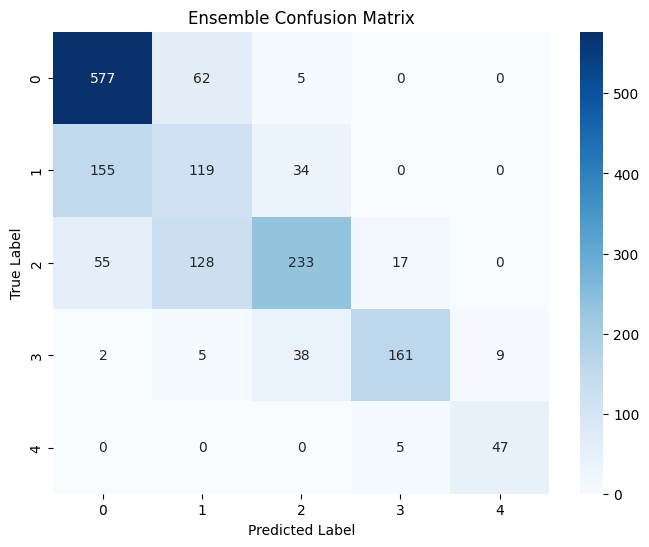

Classification Report:
               precision    recall  f1-score   support

           0     0.7313    0.8960    0.8053       644
           1     0.3790    0.3864    0.3826       308
           2     0.7516    0.5381    0.6272       433
           3     0.8798    0.7488    0.8090       215
           4     0.8393    0.9038    0.8704        52

    accuracy                         0.6883      1652
   macro avg     0.7162    0.6946    0.6989      1652
weighted avg     0.6937    0.6883    0.6824      1652



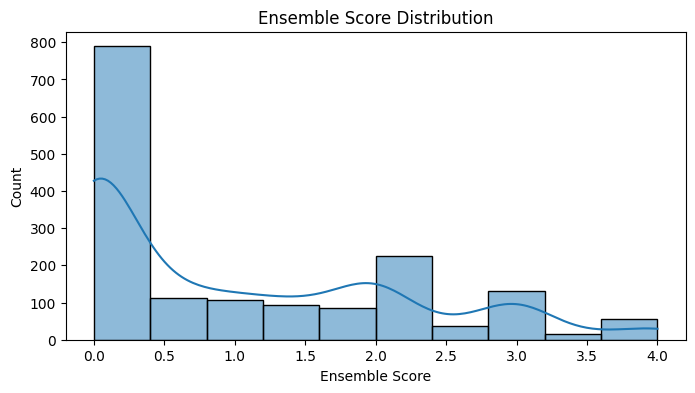

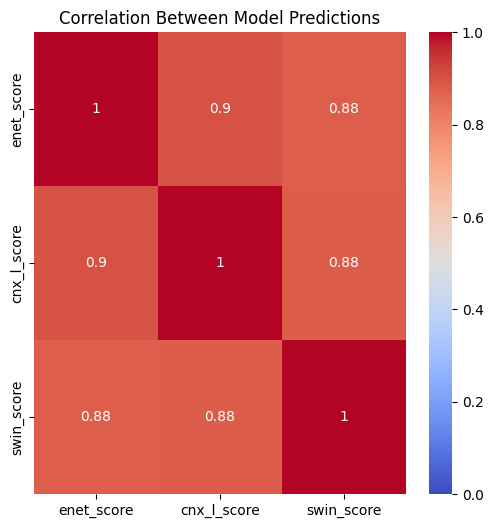

✅ Ensemble report saved: /content/drive/MyDrive/KOA_QWK_challenge/reports/ensemble_full_report.txt


In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ----------------------------
# 1. Overall QWK
# ----------------------------
print(f"✅ Final Ensemble Quadratic Weighted Kappa: {final_qwk:.4f}")

# ----------------------------
# 2. Confusion Matrix
# ----------------------------
cm = confusion_matrix(val_labels, ensemble_preds, labels=list(range(NUM_LABELS)))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(NUM_LABELS), yticklabels=range(NUM_LABELS))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Ensemble Confusion Matrix")
plt.show()

# ----------------------------
# 3. Classification Report
# ----------------------------
report = classification_report(val_labels, ensemble_preds, digits=4)
print("Classification Report:\n", report)

# ----------------------------
# 4. Ensemble Score Distribution
# ----------------------------
plt.figure(figsize=(8,4))
sns.histplot(ensemble_scores, bins=NUM_LABELS*2, kde=True)
plt.title("Ensemble Score Distribution")
plt.xlabel("Ensemble Score")
plt.ylabel("Count")
plt.show()

# ----------------------------
# 5. Model Contribution Correlation
# ----------------------------
contrib_df = ensemble_df[["enet_score", "cnx_l_score", "swin_score"]]
plt.figure(figsize=(6,6))
sns.heatmap(contrib_df.corr(), annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Correlation Between Model Predictions")
plt.show()

# ----------------------------
# 6. Save full report
# ----------------------------
report_path = PATHS["reports"] / "ensemble_full_report.txt"
with open(report_path, "w") as f:
    f.write(f"Final Ensemble QWK: {final_qwk:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)
print("✅ Ensemble report saved:", report_path)

## SECTION 19 — Interactive Ensemble Weight Dashboard

**Purpose:** Exploratory ensemble optimization.

**Reasoning:**

* Interactive weighting enables rapid sensitivity analysis.
* Demonstrates ensemble robustness beyond fixed averaging.
* Supports empirical justification of final ensemble choice.


✅ Weighted Ensemble QWK: 0.8460


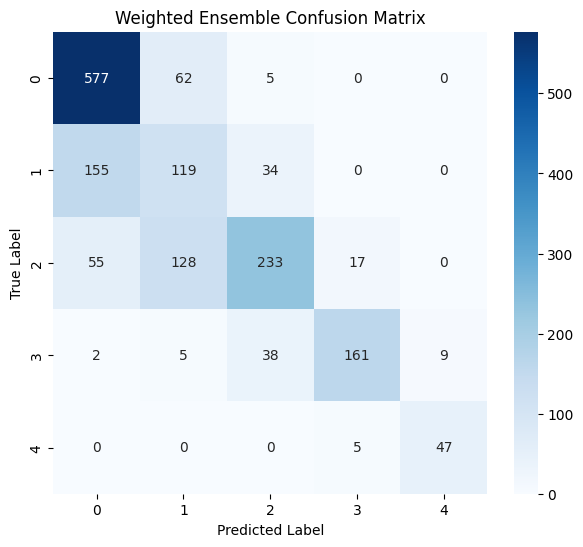

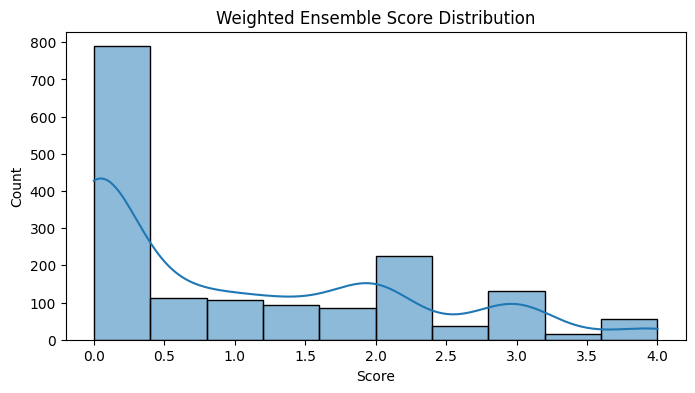

In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ----------------------------
# Sliders for model weights
# ----------------------------
w_enet = widgets.FloatSlider(value=0.33, min=0, max=1, step=0.01, description='EffNet-B5:')
w_cnxl = widgets.FloatSlider(value=0.33, min=0, max=1, step=0.01, description='ConvNeXt-L:')
w_swin = widgets.FloatSlider(value=0.34, min=0, max=1, step=0.01, description='Swin-B:')

output = widgets.Output()

def update_dashboard(*args):
    clear_output(wait=True)
    # Normalize weights safely
    weights = np.array([w_enet.value, w_cnxl.value, w_swin.value])
    if weights.sum() == 0:
        weights = np.ones_like(weights) / 3
    else:
        weights = weights / weights.sum()

    # Weighted ensemble
    weighted_scores = (weights[0]*ensemble_df['enet_score'] +
                       weights[1]*ensemble_df['cnx_l_score'] +
                       weights[2]*ensemble_df['swin_score'])

    weighted_preds = np.clip(np.round(weighted_scores), 0, NUM_LABELS-1).astype(int)
    qwk = cohen_kappa_score(val_labels, weighted_preds, weights='quadratic')

    print(f"✅ Weighted Ensemble QWK: {qwk:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(val_labels, weighted_preds, labels=list(range(NUM_LABELS)))
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(NUM_LABELS), yticklabels=range(NUM_LABELS))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Weighted Ensemble Confusion Matrix")
    plt.show()

    # Distribution of weighted scores
    plt.figure(figsize=(8,4))
    sns.histplot(weighted_scores, bins=NUM_LABELS*2, kde=True)
    plt.title("Weighted Ensemble Score Distribution")
    plt.xlabel("Score")
    plt.ylabel("Count")
    plt.show()

# Link sliders to update function
for w in [w_enet, w_cnxl, w_swin]:
    w.observe(update_dashboard, 'value')

display(widgets.VBox([w_enet, w_cnxl, w_swin, output]))
update_dashboard()
